In [107]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import norm
from sklearn.metrics import roc_curve, auc
import os

from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go
from scipy import interp
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
sys.path.insert(0, '../maldi_PIKE/maldi-learn/maldi_learn/')
sys.path.insert(0, '../Kernel/')

import warnings
warnings.filterwarnings('ignore')
import pickle

In [108]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [109]:
import seaborn as sns
palette = 'Set2'
sns.set_style('ticks')
sns.set_context('paper')
sns.set_palette(palette)

Load data

In [110]:
MALDI_type = 'peaks'
with open(f'../../MALDI data/{MALDI_type}_info_dict.pkl', 'rb') as f:
    labels_dict = pickle.load(f)

# Kernel
with open(f'../../MALDI data/{MALDI_type}_kernels.pkl', 'rb') as f:
    kernel_dict = pickle.load(f)

bins = 'Ct. bins'
kernel_matrix = kernel_dict[bins]
labels_df = labels_dict[bins]
labels_df = labels_df.reset_index()
path = '../../MALDI data/novelty/'

Analysis of the results

In [111]:
# Initialize lists to store TPR and FPR values for each model
ocsvm_tpr_values = []
ocsvm_fpr_values = []
iforest_tpr_values = []
iforest_fpr_values = []

summary = []

for filename in os.listdir(path):
    if filename.endswith('.pkl'):
        file_path = os.path.join(path, filename)
        
        # Load the pickle file
        with open(file_path, 'rb') as file:
            data = pickle.load(file)
        
        train_indices = data['train_indices']
        test_indices = data['test_indices']
        predictions = data['pred']
        
        # True labels based on the clusters
        test_labels = labels_df.loc[test_indices, 'CLUSTER']
        true_outliers_mask = test_labels.isin([1, 2])
        true_outliers_indices = test_labels.index[true_outliers_mask]
        
        # Predicted outliers
        outlier_indices = [idx for idx, pred in zip(test_indices, predictions) if pred == -1]
        
        # Calculate TP, FP, TN, FN
        tp = len([idx for idx in outlier_indices if idx in true_outliers_indices])
        fp = len([idx for idx in outlier_indices if idx not in true_outliers_indices])
        fn = len([idx for idx in true_outliers_indices if idx not in outlier_indices])
        tn = len(test_indices) - tp - fp - fn
        
        # Compute TPR and FPR
        if (tp + fn) > 0:
            tpr = tp / (tp + fn)
            if data['model_type'] == 'ocsvm':
                ocsvm_tpr_values.append(tpr)
            elif data['model_type'] == 'isolation_forest':
                iforest_tpr_values.append(tpr)
        else:
            tpr = None
        
        if (fp + tn) > 0:
            fpr = fp / (fp + tn)
            if data['model_type'] == 'ocsvm':
                ocsvm_fpr_values.append(fpr)
            elif data['model_type'] == 'isolation_forest':
                iforest_fpr_values.append(fpr)
        else:
            fpr = None

        # Retrieve clusters for each set
        train_clusters = labels_df.loc[train_indices, 'CLUSTER'].unique()
        test_clusters = labels_df.loc[test_indices, 'CLUSTER'].unique()
        outlier_clusters = labels_df.loc[outlier_indices, 'CLUSTER'].unique()
        train_period = f"{data['train_start'].date()} to {data['train_end'].date()}"
        test_period = f"{data['test_start'].date()} to {data['test_end'].date()}"
        test_cluster_counts = labels_df.loc[test_indices].groupby('CLUSTER').size()
        outlier_cluster_counts = labels_df.loc[outlier_indices].groupby('CLUSTER').size()
        outliers_2 = test_cluster_counts[2] if 2 in test_clusters else 0
        outliers_1 = test_cluster_counts[1] if 1 in test_clusters else 0
        outliers_true = outliers_2 + outliers_1
        test_cluster_counts_str = ', '.join([f"{k}: {v}" for k, v in test_cluster_counts.to_dict().items()])
        outlier_cluster_counts_str = ', '.join([f"{k}: {v}" for k, v in outlier_cluster_counts.to_dict().items()])

        summary_dict = {
            'Model Type': data['model_type'],
            'Training Period': train_period, 
            'Test Period': test_period, 
            'Train Samples': len(train_indices), 
            'Test Samples': len(test_indices), 
            'Num. Outliers Detected': len(outlier_indices),
            'Num. True Outliers': outliers_true,
            'Test Cluster Counts': test_cluster_counts_str,
            'Outlier Cluster Counts': outlier_cluster_counts_str,
            'True Positive Rate (TPR)': tpr,
            'False Positive Rate (FPR)': fpr,
        }
        summary.append(summary_dict)

In [112]:
summary_df = pd.DataFrame(summary)

fig = go.Figure(data=[go.Table(
    header=dict(values=list(summary_df.columns),
                fill_color='paleturquoise',
                align='center'),
    cells=dict(values=[summary_df[col] for col in summary_df.columns],
               fill_color='lavender',
               align='left'))
    ])

fig.show()

In [113]:
def compute_confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(n)
    h = std_err * norm.ppf((1 + confidence) / 2)
    return mean, mean - h, mean + h

In [120]:
# Compute mean TPR and FPR with confidence intervals for OCSVM
ocsvm_mean_tpr, ocsvm_tpr_ci_low, ocsvm_tpr_ci_high = compute_confidence_interval(ocsvm_tpr_values)
ocsvm_mean_fpr, ocsvm_fpr_ci_low, ocsvm_fpr_ci_high = compute_confidence_interval(ocsvm_fpr_values)

# Compute mean TPR and FPR with confidence intervals for Isolation Forest
iforest_mean_tpr, iforest_tpr_ci_low, iforest_tpr_ci_high = compute_confidence_interval(iforest_tpr_values)
iforest_mean_fpr, iforest_fpr_ci_low, iforest_fpr_ci_high = compute_confidence_interval(iforest_fpr_values)

print(f"OCSVM Mean TPR: {ocsvm_mean_tpr:.3f} (95% CI: {max(ocsvm_tpr_ci_low, 0.0):.3f} - {ocsvm_tpr_ci_high:.3f})")
print(f"OCSVM Mean FPR: {ocsvm_mean_fpr:.3f} (95% CI: {max(ocsvm_fpr_ci_low, 0.0):.3f} - {ocsvm_fpr_ci_high:.3f})")

print(f"Isolation Forest Mean TPR: {iforest_mean_tpr:.3f} (95% CI: {max(iforest_tpr_ci_low, 0.0):.3f} - {iforest_tpr_ci_high:.3f})")
print(f"Isolation Forest Mean FPR: {iforest_mean_fpr:.3f} (95% CI: {max(iforest_fpr_ci_low, 0.0):.3f} - {iforest_fpr_ci_high:.3f})")

OCSVM Mean TPR: 0.742 (95% CI: 0.668 - 0.816)
OCSVM Mean FPR: 0.238 (95% CI: 0.138 - 0.338)
Isolation Forest Mean TPR: 0.154 (95% CI: 0.093 - 0.215)
Isolation Forest Mean FPR: 0.051 (95% CI: 0.000 - 0.111)


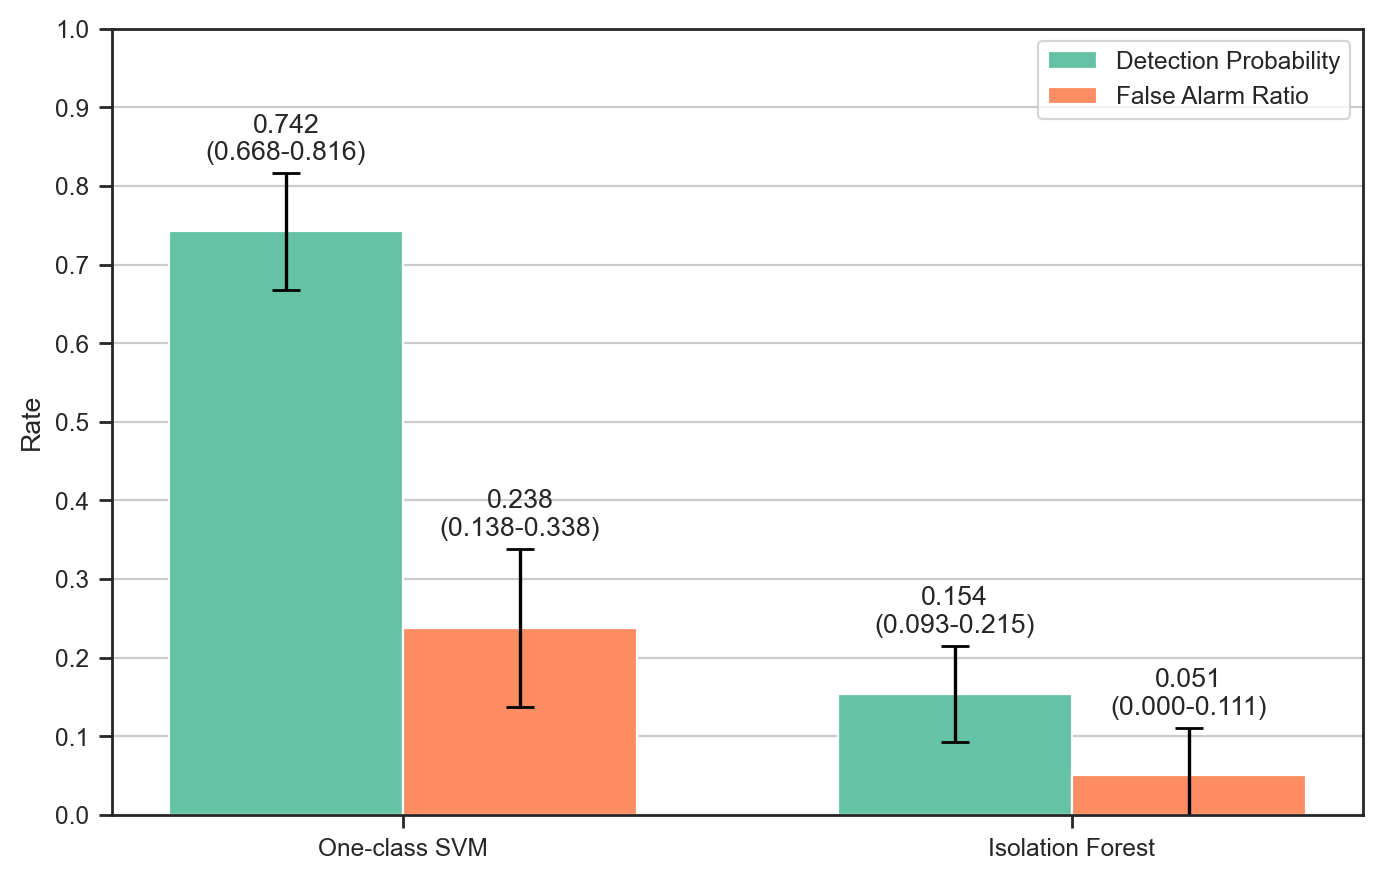

In [121]:
# Prepare data for plotting
labels = ['One-class SVM', 'Isolation Forest']
mean_tprs = [ocsvm_mean_tpr, iforest_mean_tpr]
mean_fprs = [ocsvm_mean_fpr, iforest_mean_fpr]
tpr_errors = [[ocsvm_mean_tpr - ocsvm_tpr_ci_low, iforest_mean_tpr - iforest_tpr_ci_low],
              [ocsvm_tpr_ci_high - ocsvm_mean_tpr, iforest_tpr_ci_high - iforest_mean_tpr]]
fpr_errors = [[ocsvm_mean_fpr - ocsvm_fpr_ci_low, iforest_mean_fpr - iforest_fpr_ci_low],
              [ocsvm_fpr_ci_high - ocsvm_mean_fpr, iforest_fpr_ci_high - iforest_mean_fpr]]
sample_sizes_tpr = [len(ocsvm_tpr_values), len(iforest_tpr_values)]
sample_sizes_fpr = [len(ocsvm_fpr_values), len(iforest_fpr_values)]

# Plotting
x = np.arange(len(labels))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(7, 4.5))

# Plot TPR
tpr_bars = ax.bar(x - width/2, mean_tprs, width, label='Detection Probability', yerr=tpr_errors, capsize=5)

# Plot FPR
fpr_bars = ax.bar(x + width/2, mean_fprs, width, label='False Alarm Ratio', yerr=fpr_errors, capsize=5)

# Add labels, title, and custom x-axis tick labels
ax.set_ylabel('Rate')
ax.set_ylim(0.0, 1.0)
ax.set_yticks(np.arange(0.0, 1.1, 0.1))
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add a grid
ax.yaxis.grid(True)

# Function to add value annotations to the bars
def autolabel(bars, errors, sample_sizes):
    """Attach a text label above each bar displaying its height."""
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ci_low, ci_high = errors[0][i], errors[1][i]
        N = sample_sizes[i]
        ax.annotate(f'{height:.3f}\n({max(height-ci_low, 0.0):.3f}-{height+ci_high:.3f})',
                    xy=(bar.get_x() + bar.get_width() / 2, height + ci_high),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

# Annotate the bars with a larger offset to avoid overlap
autolabel(tpr_bars, tpr_errors, sample_sizes_tpr)
autolabel(fpr_bars, fpr_errors, sample_sizes_fpr)

# Display the plot
plt.tight_layout()

plt.savefig('c:/Users/rafar/Desktop/UC3M/2nd Semester/6 Master Thesis/Images/novelty_detection.png', dpi=500)
plt.show() 

Generate *.csv files

In [116]:
# csv_file_path = 'summary_1p_cluster0.csv'
# summary_df.to_csv(csv_file_path, index=False)